# 📈 Chủ đề 1: Phân tích Doanh thu & Seasonality (V3.1)

**Mục tiêu**: Phân tích 4 cấp độ D → D → P → P (DDDP Framework)

## 4 Cấp độ phân tích
```
Descriptive  →  Diagnostic  →  Predictive  →  Prescriptive
(What?)          (Why?)         (What next?)    (What to do?)
```

### Mục lục
1. [Setup & Load Data](#1--setup--load-data)
2. [Cấp độ 1: Descriptive - Mô tả](#2--cấp-độ-1-descriptive--mô-tả)
3. [Cấp độ 2: Diagnostic - Chẩn đoán](#3--cấp-độ-2-diagnostic--chẩn-đoán)
4. [Cấp độ 3: Predictive - Dự đoán](#4--cấp-độ-3-predictive--dự-đoán)
5. [Cấp độ 4: Prescriptive - Đề xuất](#5--cấp-độ-4-prescriptive--đề-xuất)
6. [Tổng kết & Khuyến nghị](#6--tổng-kết--khuyến-nghị)

---

## 1 — Setup & Load Data

In [20]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Config
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

DATA_DIR = '../data/'
OUTPUT_DIR = './FINAL_DELIVERABLES/'

In [22]:
# Load data
sales = pd.read_csv(DATA_DIR + 'sales.csv', parse_dates=['Date'])
orders = pd.read_csv(DATA_DIR + 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(DATA_DIR + 'order_items.csv', low_memory=False)
promotions = pd.read_csv(DATA_DIR + 'promotions.csv')
web_traffic = pd.read_csv(DATA_DIR + 'web_traffic.csv', parse_dates=['date'])

print("✅ Data loaded")
print(f"   Sales: {len(sales):,} rows ({sales['Date'].min().date()} to {sales['Date'].max().date()})")
print(f"   Orders: {len(orders):,} rows")
print(f"   Web Traffic: {len(web_traffic):,} rows")

✅ Data loaded
   Sales: 3,833 rows (2012-07-04 to 2022-12-31)
   Orders: 646,945 rows
   Web Traffic: 3,652 rows


In [23]:
# Feature Engineering

# Sales features
sales['year'] = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.month
sales['quarter'] = sales['Date'].dt.quarter
sales['year_month'] = sales['Date'].dt.to_period('M')
sales['day_of_week'] = sales['Date'].dt.dayofweek
sales['is_weekend'] = sales['day_of_week'].isin([5, 6]).astype(int)
sales['is_tet'] = sales['month'].isin([1, 2]).astype(int)
sales['is_sale_season'] = sales['month'].isin([11, 12]).astype(int)
sales['Date_only'] = sales['Date'].dt.date

# Gross Margin
sales['GM'] = (sales['Revenue'] - sales['COGS']) / sales['Revenue']

# Orders features
orders['year'] = orders['order_date'].dt.year
orders['month'] = orders['order_date'].dt.month
orders['year_month'] = orders['order_date'].dt.to_period('M')
orders['Date_only'] = orders['order_date'].dt.date

# Web traffic features
web_traffic['year'] = web_traffic['date'].dt.year
web_traffic['month'] = web_traffic['date'].dt.month
web_traffic['year_month'] = web_traffic['date'].dt.to_period('M')
web_traffic['Date_only'] = web_traffic['date'].dt.date

print("✅ Features created")
print(f"   Year range: {sales['year'].min()} - {sales['year'].max()}")
print(f"   Date range: {sales['Date'].min().date()} to {sales['Date'].max().date()}")

✅ Features created
   Year range: 2012 - 2022
   Date range: 2012-07-04 to 2022-12-31


---

## 2 — Cấp độ 1: DESCRIPTIVE — Mô tả

**Câu hỏi**: Doanh thu thay đổi như thế nào theo thời gian?

In [24]:
# Tổng quan Doanh thu
total_revenue = sales['Revenue'].sum()
total_cogs = sales['COGS'].sum()
avg_daily_rev = sales['Revenue'].mean()
avg_gm = sales['GM'].mean()

print("="*60)
print("DOANH THU & LỢI NHUẬN TỔNG QUAN (2012-2022)")
print("="*60)
print(f"Tổng Revenue:   {total_revenue:>18,.0f} VND")
print(f"Tổng COGS:      {total_cogs:>18,.0f} VND")
print(f"Tổng Lợi nhuận: {total_revenue - total_cogs:>18,.0f} VND")
print(f"GM trung bình:  {avg_gm:>17.2%}")
print(f"Revenue TB/ngày: {avg_daily_rev:>18,.0f} VND")
print(f"Số ngày dữ liệu: {len(sales):>17,} ngày")

DOANH THU & LỢI NHUẬN TỔNG QUAN (2012-2022)
Tổng Revenue:       16,430,476,586 VND
Tổng COGS:          14,163,450,519 VND
Tổng Lợi nhuận:      2,267,026,066 VND
GM trung bình:             12.54%
Revenue TB/ngày:          4,286,584 VND
Số ngày dữ liệu:             3,833 ngày


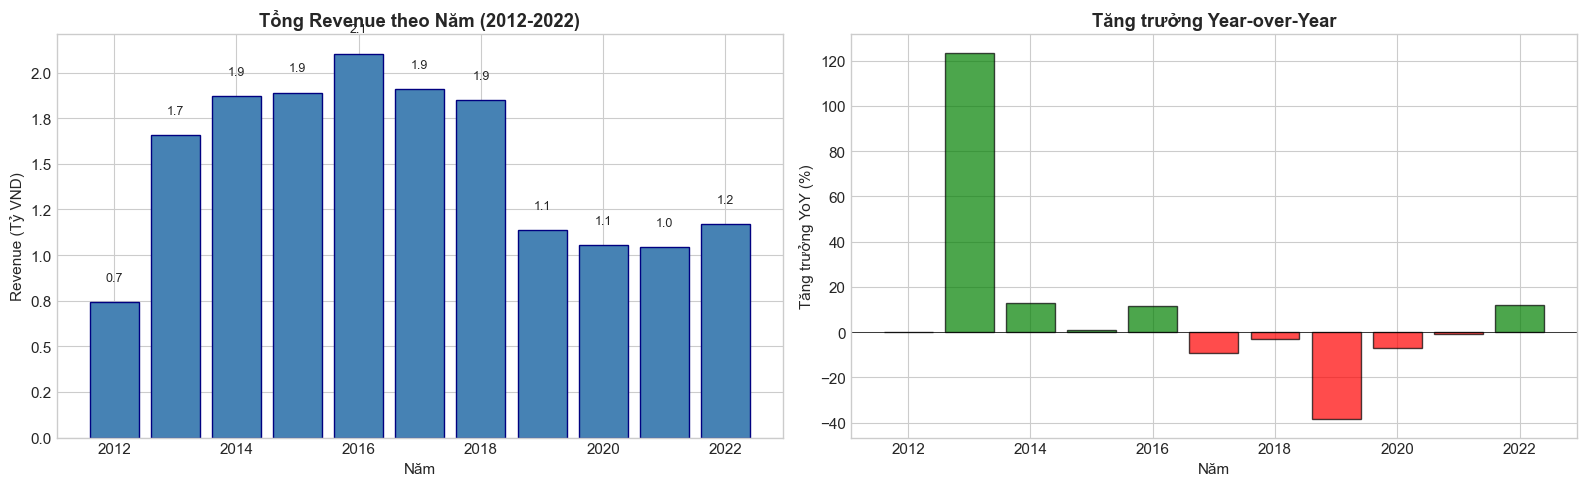


📊 Biểu đồ đã lưu: revenue_by_year.png


In [25]:
# Revenue by Year
rev_year = sales.groupby('year')['Revenue'].sum().reset_index()
rev_year['YoY_growth'] = rev_year['Revenue'].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: Revenue by Year
ax1 = axes[0]
bars = ax1.bar(rev_year['year'], rev_year['Revenue']/1e9, color='steelblue', edgecolor='navy')
ax1.set_xlabel('Năm')
ax1.set_ylabel('Revenue (Tỷ VND)')
ax1.set_title('Tổng Revenue theo Năm (2012-2022)', fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.1f}'))

# Add value labels
for bar, val in zip(bars, rev_year['Revenue']/1e9):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{val:.1f}', ha='center', va='bottom', fontsize=9)

# Chart 2: YoY Growth
ax2 = axes[1]
colors = ['green' if x > 0 else 'red' for x in rev_year['YoY_growth'].fillna(0)]
bars2 = ax2.bar(rev_year['year'], rev_year['YoY_growth'].fillna(0), color=colors, edgecolor='black', alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Năm')
ax2.set_ylabel('Tăng trưởng YoY (%)')
ax2.set_title('Tăng trưởng Year-over-Year', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'revenue_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Biểu đồ đã lưu: revenue_by_year.png")

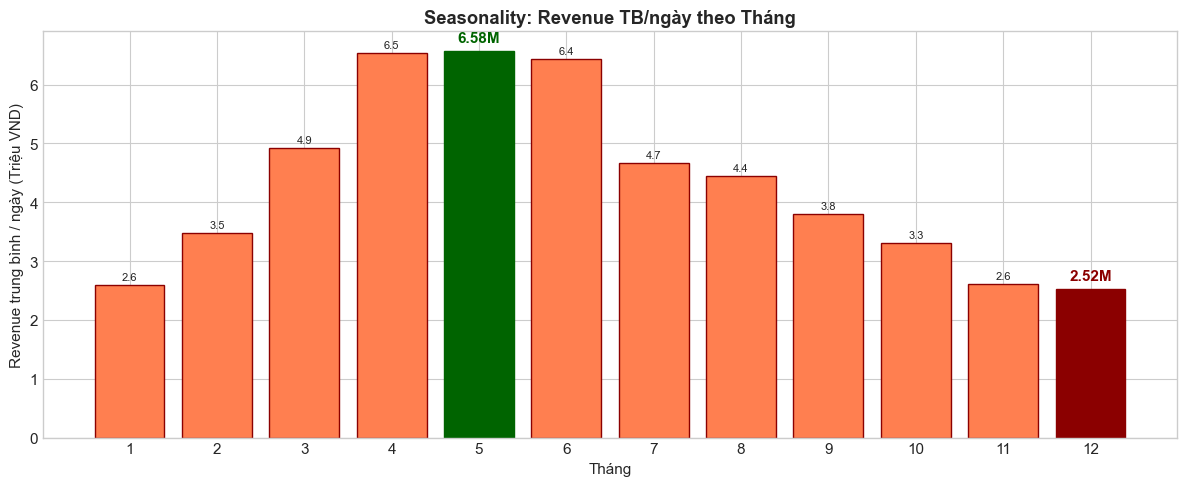


📊 Biểu đồ đã lưu: revenue_by_month.png

📈 Tháng tốt nhất: 5 (6.58M/ngày)
📉 Tháng kém nhất: 12 (2.52M/ngày)


In [26]:
# Revenue by Month (Seasonality)
rev_month = sales.groupby('month')['Revenue'].agg(['sum', 'mean']).reset_index()
rev_month.columns = ['month', 'total', 'avg']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(rev_month['month'], rev_month['avg']/1e6, color='coral', edgecolor='darkred')
ax.set_xlabel('Tháng')
ax.set_ylabel('Revenue trung bình / ngày (Triệu VND)')
ax.set_title('Seasonality: Revenue TB/ngày theo Tháng', fontweight='bold')
ax.set_xticks(range(1, 13))

# Highlight peak and low months
max_val = rev_month['avg'].max()
min_val = rev_month['avg'].min()
for bar, avg in zip(bars, rev_month['avg']):
    if avg == max_val:
        bar.set_color('darkgreen')
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                f'{avg/1e6:.2f}M', ha='center', va='bottom', fontweight='bold', color='darkgreen')
    elif avg == min_val:
        bar.set_color('darkred')
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                f'{avg/1e6:.2f}M', ha='center', va='bottom', fontweight='bold', color='darkred')
    else:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                f'{avg/1e6:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'revenue_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Biểu đồ đã lưu: revenue_by_month.png")
print(f"\n📈 Tháng tốt nhất: {rev_month.loc[rev_month['avg'].idxmax(), 'month']} ({max_val/1e6:.2f}M/ngày)")
print(f"📉 Tháng kém nhất: {rev_month.loc[rev_month['avg'].idxmin(), 'month']} ({min_val/1e6:.2f}M/ngày)")

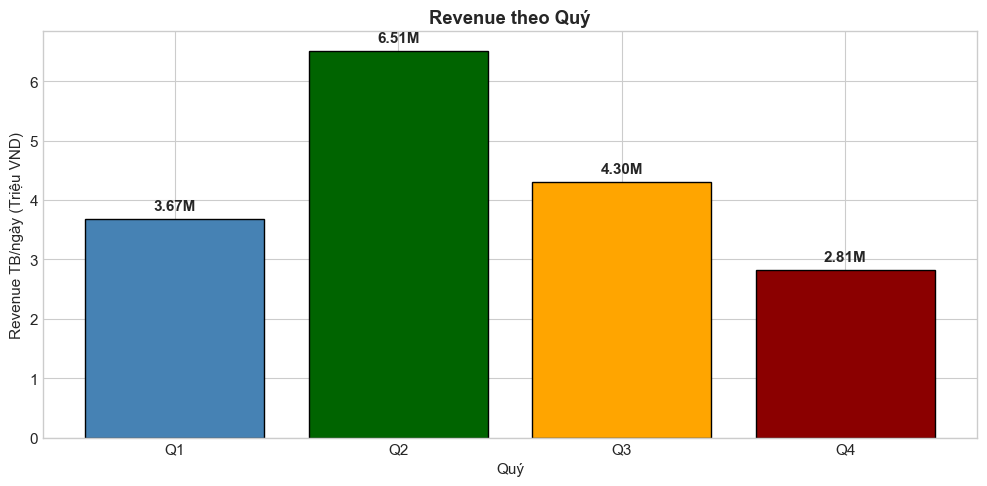


📊 Biểu đồ đã lưu: revenue_by_quarter.png


In [27]:
# Revenue by Quarter
rev_quarter = sales.groupby('quarter')['Revenue'].agg(['sum', 'mean']).reset_index()
rev_quarter.columns = ['quarter', 'total', 'avg']

fig, ax = plt.subplots(figsize=(10, 5))
quarters = ['Q1', 'Q2', 'Q3', 'Q4']
colors = ['steelblue', 'darkgreen', 'orange', 'darkred']
bars = ax.bar(quarters, rev_quarter['avg']/1e6, color=colors, edgecolor='black')
ax.set_xlabel('Quý')
ax.set_ylabel('Revenue TB/ngày (Triệu VND)')
ax.set_title('Revenue theo Quý', fontweight='bold')

for bar, val in zip(bars, rev_quarter['avg']/1e6):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
            f'{val:.2f}M', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'revenue_by_quarter.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Biểu đồ đã lưu: revenue_by_quarter.png")

In [28]:
# Weekday vs Weekend Analysis
weekday_rev = sales.groupby('is_weekend')['Revenue'].agg(['sum', 'mean', 'count'])
weekday_rev.index = ['Weekday', 'Weekend']

print("\n📊 Weekday vs Weekend Analysis:")
print(weekday_rev)

# Statistical test
weekday_data = sales[sales['is_weekend'] == 0]['Revenue']
weekend_data = sales[sales['is_weekend'] == 1]['Revenue']
t_stat, p_value = stats.ttest_ind(weekday_data, weekend_data)

print(f"\n📈 Weekday avg: {weekday_data.mean()/1e6:.2f}M VND/ngày")
print(f"📉 Weekend avg: {weekend_data.mean()/1e6:.2f}M VND/ngày")
print(f"📊 Chênh lệch: {(weekday_data.mean() - weekend_data.mean())/1e6:.2f}M VND ({abs(weekday_data.mean() - weekend_data.mean())/weekend_data.mean()*100:.1f}%)")
print(f"\n📋 Statistical Test: t-statistic = {t_stat:.4f}, p-value = {p_value:.6f}")
if p_value < 0.05:
    print("✅ Result: Significant (p < 0.05)")
else:
    print("❌ Result: Not significant (p >= 0.05)")


📊 Weekday vs Weekend Analysis:
                  sum          mean  count
Weekday  1.206127e+10  4.405140e+06   2738
Weekend  4.369204e+09  3.990141e+06   1095

📈 Weekday avg: 4.41M VND/ngày
📉 Weekend avg: 3.99M VND/ngày
📊 Chênh lệch: 0.41M VND (10.4%)

📋 Statistical Test: t-statistic = 4.4325, p-value = 0.000010
✅ Result: Significant (p < 0.05)


---

## 3 — Cấp độ 2: DIAGNOSTIC — Chẩn đoán

**Câu hỏi**: Tại sao doanh thu tăng/giảm? Nguyên nhân là gì?

In [29]:
# Revenue Drivers Framework
print("\n📊 REVENUE DRIVERS FRAMEWORK")
print("="*60)
print("Revenue = Orders × AOV")
print("Orders = Sessions × Conversion Rate")
print("=> Revenue = Sessions × Conversion × AOV")
print("="*60)


📊 REVENUE DRIVERS FRAMEWORK
Revenue = Orders × AOV
Orders = Sessions × Conversion Rate
=> Revenue = Sessions × Conversion × AOV


In [30]:
# Monthly aggregation
# Monthly sales
monthly_sales = sales.groupby(['year', 'month']).agg({
    'Revenue': 'sum',
    'COGS': 'sum',
    'GM': 'mean'
}).reset_index()

# Monthly orders
monthly_orders = orders.groupby(['year', 'month']).agg({
    'order_id': 'count',
    'customer_id': 'nunique'
}).reset_index()
monthly_orders.columns = ['year', 'month', 'orders', 'customers']

# Monthly web traffic
monthly_traffic = web_traffic.groupby(['year', 'month']).agg({
    'sessions': 'sum',
    'unique_visitors': 'sum'
}).reset_index()

# Merge all
monthly = monthly_sales.merge(monthly_orders, on=['year', 'month'], how='left')
monthly = monthly.merge(monthly_traffic, on=['year', 'month'], how='left')

# Add quarter
monthly['quarter'] = ((monthly['month'] - 1) // 3 + 1).astype(int)

# Calculate derived metrics
monthly['AOV'] = monthly['Revenue'] / monthly['orders']
monthly['conversion_rate'] = monthly['orders'] / monthly['sessions'] * 100

print("✅ Monthly metrics calculated")
print(f"   Monthly records: {len(monthly)}")

✅ Monthly metrics calculated
   Monthly records: 126


In [31]:
# Quarterly Driver Comparison
quarterly = monthly.groupby('quarter').agg({
    'Revenue': 'mean',
    'orders': 'mean',
    'AOV': 'mean',
    'sessions': 'mean',
    'conversion_rate': 'mean'
}).reset_index()

print("\n📊 QUARTERLY DRIVERS COMPARISON")
print("="*80)
print(f"{'Metric':<15} {'Q2 (Cao)':>15} {'Q4 (Thấp)':>15} {'Diff':>12} {'%Diff':>10}")
print("-"*80)

for _, row in quarterly.iterrows():
    q = int(row['quarter'])
    if q == 2:
        label = "Q2 (Cao)"
    elif q == 4:
        label = "Q4 (Thấp)"
    else:
        label = f"Q{q}"
    print(f"{row['Revenue']/1e6:>15.2f}M {row['orders']:>15,.0f} {row['AOV']:>15,.0f} {row['sessions']/1e3:>12.1f}K {row['conversion_rate']:>10.2f}%")

# Q2 vs Q4 specific comparison
q2_data = monthly[monthly['quarter'] == 2]
q4_data = monthly[monthly['quarter'] == 4]

q2_rev = q2_data['Revenue'].mean()
q4_rev = q4_data['Revenue'].mean()
q2_ses = q2_data['sessions'].mean()
q4_ses = q4_data['sessions'].mean()
q2_conv = q2_data['conversion_rate'].mean()
q4_conv = q4_data['conversion_rate'].mean()

print("\n📊 KEY FINDING - Q2 vs Q4:")
print(f"   Revenue: Q2 {q2_rev/1e6:.2f}M vs Q4 {q4_rev/1e6:.2f}M ({((q2_rev-q4_rev)/q4_rev*100):+.0f}%)")
print(f"   Sessions: Q2 {q2_ses/1e3:.1f}K vs Q4 {q4_ses/1e3:.1f}K ({((q2_ses-q4_ses)/q4_ses*100):+.0f}%)")
print(f"   Conversion: Q2 {q2_conv:.2f}% vs Q4 {q4_conv:.2f}% ({((q2_conv-q4_conv)/q4_conv*100):+.0f}%)")
print("\n⚠️ IMPORTANT: Q4 conversion CAO HƠN Q2!")
print("   => Q4 thấp chủ yếu do TRAFFIC thấp, không phải CONVERSION thấp")


📊 QUARTERLY DRIVERS COMPARISON
Metric                 Q2 (Cao)       Q4 (Thấp)         Diff      %Diff
--------------------------------------------------------------------------------
         110.42M           4,064          28,310        602.1K       0.73%
         197.55M           7,352          27,860       1088.6K       0.72%
         131.60M           5,383          25,466        841.2K       0.69%
          86.33M           3,843          24,270        516.6K       0.78%

📊 KEY FINDING - Q2 vs Q4:
   Revenue: Q2 197.55M vs Q4 86.33M (+129%)
   Sessions: Q2 1088.6K vs Q4 516.6K (+111%)
   Conversion: Q2 0.72% vs Q4 0.78% (-8%)

⚠️ IMPORTANT: Q4 conversion CAO HƠN Q2!
   => Q4 thấp chủ yếu do TRAFFIC thấp, không phải CONVERSION thấp


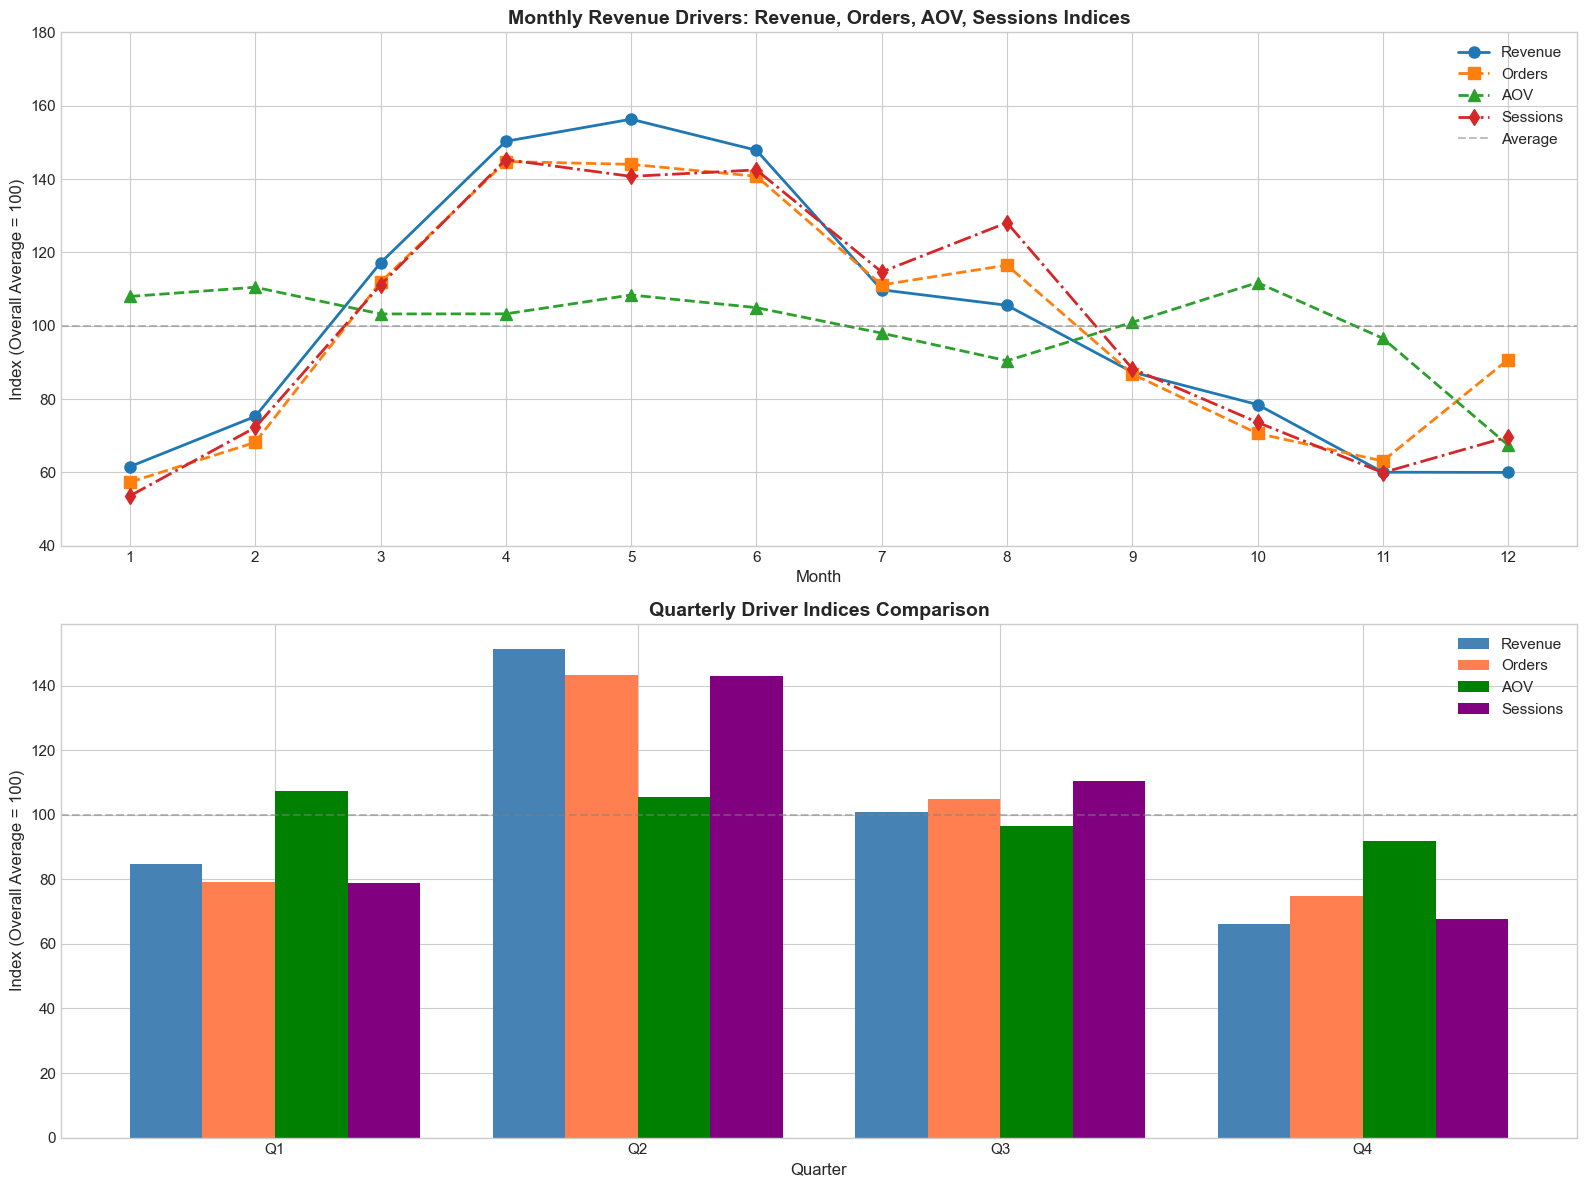


📊 Biểu đồ đã lưu: monthly_revenue_drivers.png


In [32]:
# Monthly Revenue Drivers Chart
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Calculate indices
overall_avg_rev = monthly['Revenue'].mean()
overall_avg_orders = monthly['orders'].mean()
overall_avg_aov = monthly['AOV'].mean()
overall_avg_sessions = monthly['sessions'].mean()
overall_avg_conv = monthly['conversion_rate'].mean()

monthly['rev_index'] = monthly['Revenue'] / overall_avg_rev * 100
monthly['orders_index'] = monthly['orders'] / overall_avg_orders * 100
monthly['aov_index'] = monthly['AOV'] / overall_avg_aov * 100
monthly['sessions_index'] = monthly['sessions'] / overall_avg_sessions * 100
monthly['conversion_index'] = monthly['conversion_rate'] / overall_avg_conv * 100

# Top: Line chart of all indices by month
ax1 = axes[0]
months_order = range(1, 13)
ax1.plot(months_order, monthly.groupby('month')['rev_index'].mean(), 'o-', label='Revenue', linewidth=2, markersize=8)
ax1.plot(months_order, monthly.groupby('month')['orders_index'].mean(), 's--', label='Orders', linewidth=2, markersize=8)
ax1.plot(months_order, monthly.groupby('month')['aov_index'].mean(), '^--', label='AOV', linewidth=2, markersize=8)
ax1.plot(months_order, monthly.groupby('month')['sessions_index'].mean(), 'd-.', label='Sessions', linewidth=2, markersize=8)
ax1.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='Average')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Index (Overall Average = 100)', fontsize=12)
ax1.set_title('Monthly Revenue Drivers: Revenue, Orders, AOV, Sessions Indices', fontweight='bold', fontsize=14)
ax1.legend(loc='upper right')
ax1.set_xticks(months_order)
ax1.set_ylim([40, 180])

# Bottom: Grouped bar by quarter
ax2 = axes[1]
quarters = ['Q1', 'Q2', 'Q3', 'Q4']
x = np.arange(len(quarters))
width = 0.2

rev_by_q = [monthly[monthly['quarter']==q]['rev_index'].mean() for q in [1,2,3,4]]
ord_by_q = [monthly[monthly['quarter']==q]['orders_index'].mean() for q in [1,2,3,4]]
aov_by_q = [monthly[monthly['quarter']==q]['aov_index'].mean() for q in [1,2,3,4]]
ses_by_q = [monthly[monthly['quarter']==q]['sessions_index'].mean() for q in [1,2,3,4]]

bars1 = ax2.bar(x - 1.5*width, rev_by_q, width, label='Revenue', color='steelblue')
bars2 = ax2.bar(x - 0.5*width, ord_by_q, width, label='Orders', color='coral')
bars3 = ax2.bar(x + 0.5*width, aov_by_q, width, label='AOV', color='green')
bars4 = ax2.bar(x + 1.5*width, ses_by_q, width, label='Sessions', color='purple')
ax2.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Quarter', fontsize=12)
ax2.set_ylabel('Index (Overall Average = 100)', fontsize=12)
ax2.set_title('Quarterly Driver Indices Comparison', fontweight='bold', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(quarters)
ax2.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'monthly_revenue_drivers.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Biểu đồ đã lưu: monthly_revenue_drivers.png")


📊 CORRELATION BETWEEN DRIVERS:
                 Revenue  orders    AOV  sessions  conversion_rate
Revenue            1.000   0.925 -0.092     0.458            0.441
orders             0.925   1.000 -0.436     0.283            0.659
AOV               -0.092  -0.436  1.000     0.340           -0.706
sessions           0.458   0.283  0.340     1.000           -0.443
conversion_rate    0.441   0.659 -0.706    -0.443            1.000

📈 Key Correlations:
   Revenue-Orders: r = 0.925 (Very strong)
   Revenue-Sessions: r = 0.458 (Moderate)
   Revenue-Conversion: r = 0.441 (Moderate)
   AOV-Conversion: r = -0.706 (Negative)


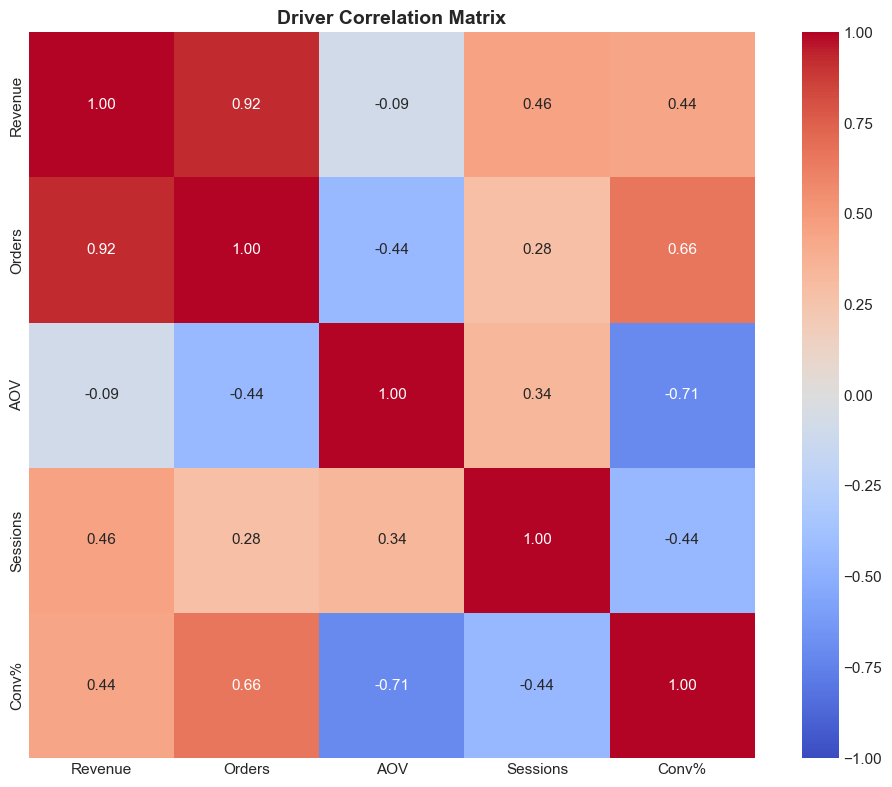


📊 Biểu đồ đã lưu: driver_contribution.png


In [33]:
# Driver Correlation Matrix
corr_cols = ['Revenue', 'orders', 'AOV', 'sessions', 'conversion_rate']
corr_matrix = monthly[corr_cols].corr()

print("\n📊 CORRELATION BETWEEN DRIVERS:")
print(corr_matrix.round(3))

# Key insights
print("\n📈 Key Correlations:")
print(f"   Revenue-Orders: r = {corr_matrix.loc['Revenue', 'orders']:.3f} (Very strong)")
print(f"   Revenue-Sessions: r = {corr_matrix.loc['Revenue', 'sessions']:.3f} (Moderate)")
print(f"   Revenue-Conversion: r = {corr_matrix.loc['Revenue', 'conversion_rate']:.3f} (Moderate)")
print(f"   AOV-Conversion: r = {corr_matrix.loc['AOV', 'conversion_rate']:.3f} (Negative)")

# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr_plot = monthly[['rev_index', 'orders_index', 'aov_index', 'sessions_index', 'conversion_index']].corr()
corr_plot.columns = ['Revenue', 'Orders', 'AOV', 'Sessions', 'Conv%']
corr_plot.index = ['Revenue', 'Orders', 'AOV', 'Sessions', 'Conv%']
sns.heatmap(corr_plot, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            vmin=-1, vmax=1, square=True)
ax.set_title('Driver Correlation Matrix', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'driver_contribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Biểu đồ đã lưu: driver_contribution.png")

---

## 4 — Cấp độ 3: PREDICTIVE — Dự đoán

**Câu hỏi**: Xu hướng nào sẽ lặp lại? Pattern nào đáng tin cậy?

In [34]:
# Seasonality Stability Analysis
monthly_stats = monthly.groupby('month').agg({
    'rev_index': ['mean', 'std', 'min', 'max', 'count']
}).reset_index()
monthly_stats.columns = ['month', 'avg_index', 'std', 'min_index', 'max_index', 'n_years']
monthly_stats['cv'] = monthly_stats['std'] / monthly_stats['avg_index'] * 100

# Rank stability
monthly['month_rank'] = monthly.groupby('year')['Revenue'].rank(ascending=False)
rank_counts = monthly.groupby('month')['month_rank'].agg(['mean', 'std']).reset_index()
rank_counts.columns = ['month', 'avg_rank', 'rank_std']
monthly_stats = monthly_stats.merge(rank_counts, on='month')

# Confidence level
def assign_confidence(row):
    cv = row['cv']
    if cv < 20:
        return 'Cao'
    elif cv < 25:
        return 'Trung bình'
    else:
        return 'Thấp'

monthly_stats['confidence'] = monthly_stats.apply(assign_confidence, axis=1)

print("\n📊 SEASONALITY STABILITY STATISTICS")
print("="*90)
print(f"{'Tháng':<6} {'Avg Index':>10} {'Std':>8} {'CV%':>6} {'Min':>8} {'Max':>8} {'Conf':>12}")
print("-"*90)
for _, row in monthly_stats.iterrows():
    print(f"{int(row['month']):<6} {row['avg_index']:>9.1f}% {row['std']:>7.1f} {row['cv']:>5.1f}% {row['min_index']:>7.0f}% {row['max_index']:>7.0f}% {row['confidence']:>12}")

print("\n⚠️ KEY FINDING: Không có tháng nào có stability CAO (CV < 15%)")
print("   Direction của seasonality đáng tin hơn magnitude")


📊 SEASONALITY STABILITY STATISTICS
Tháng   Avg Index      Std    CV%      Min      Max         Conf
------------------------------------------------------------------------------------------
1           61.6%    17.6  28.5%      36%      90%         Thấp
2           75.3%    17.8  23.7%      48%      99%   Trung bình
3          117.2%    22.9  19.5%      86%     144%          Cao
4          150.3%    41.0  27.3%     103%     205%         Thấp
5          156.3%    44.7  28.6%     102%     206%         Thấp
6          147.9%    46.8  31.6%      85%     208%         Thấp
7          109.8%    30.2  27.5%      70%     145%         Thấp
8          105.6%    38.3  36.3%      52%     174%         Thấp
9           87.4%    21.8  24.9%      57%     119%   Trung bình
10          78.5%    21.1  26.9%      50%     107%         Thấp
11          60.1%    18.4  30.6%      35%      81%         Thấp
12          60.0%    21.0  34.9%      33%      88%         Thấp

⚠️ KEY FINDING: Không có tháng nào có s

In [35]:
# Monthly Index by Year Heatmap
monthly_index_by_year = monthly.pivot(index='month', columns='year', values='rev_index')

print("\n📊 MONTHLY REVENUE INDEX BY YEAR:")
print(monthly_index_by_year.round(0).to_string())

# Add trend column
trends = []
for month in monthly_index_by_year.index:
    values = monthly_index_by_year.loc[month].values
    if len(values) > 1:
        # Check trend: early years vs recent years
        early = values[:5].mean() if len(values) >= 5 else values.mean()
        recent = values[-5:].mean() if len(values) >= 5 else values.mean()
        if recent < early * 0.9:
            trends.append("↓")
        elif recent > early * 1.1:
            trends.append("↑")
        else:
            trends.append("→")
    else:
        trends.append("-")

print("\n📈 TREND: Most months show declining seasonality (↓)")
print("   Peak months (Apr-Jun) were 200%+ in 2015-2018, now only 100-110%")


📊 MONTHLY REVENUE INDEX BY YEAR:
year    2012   2013   2014   2015   2016   2017   2018   2019   2020   2021   2022
month                                                                             
1        NaN   70.0   70.0   69.0   90.0   73.0   70.0   56.0   37.0   36.0   46.0
2        NaN   84.0   83.0   93.0   99.0   84.0   85.0   65.0   48.0   51.0   61.0
3        NaN  116.0  141.0  131.0  137.0  144.0  130.0   93.0   86.0   87.0  105.0
4        NaN  153.0  178.0  199.0  205.0  176.0  169.0  104.0  107.0  103.0  108.0
5        NaN  154.0  187.0  184.0  206.0  202.0  202.0  111.0  102.0  110.0  107.0
6        NaN  152.0  160.0  166.0  195.0  205.0  208.0  106.0   85.0   99.0  104.0
7      100.0  127.0  130.0  131.0  137.0  145.0  140.0   76.0   70.0   77.0   75.0
8      122.0   89.0  150.0   92.0  174.0   90.0  149.0   62.0   94.0   52.0   87.0
9       99.0   98.0   93.0  119.0  111.0  103.0   90.0   64.0   60.0   57.0   66.0
10      84.0   88.0   93.0  107.0   98.0  101.0   77.

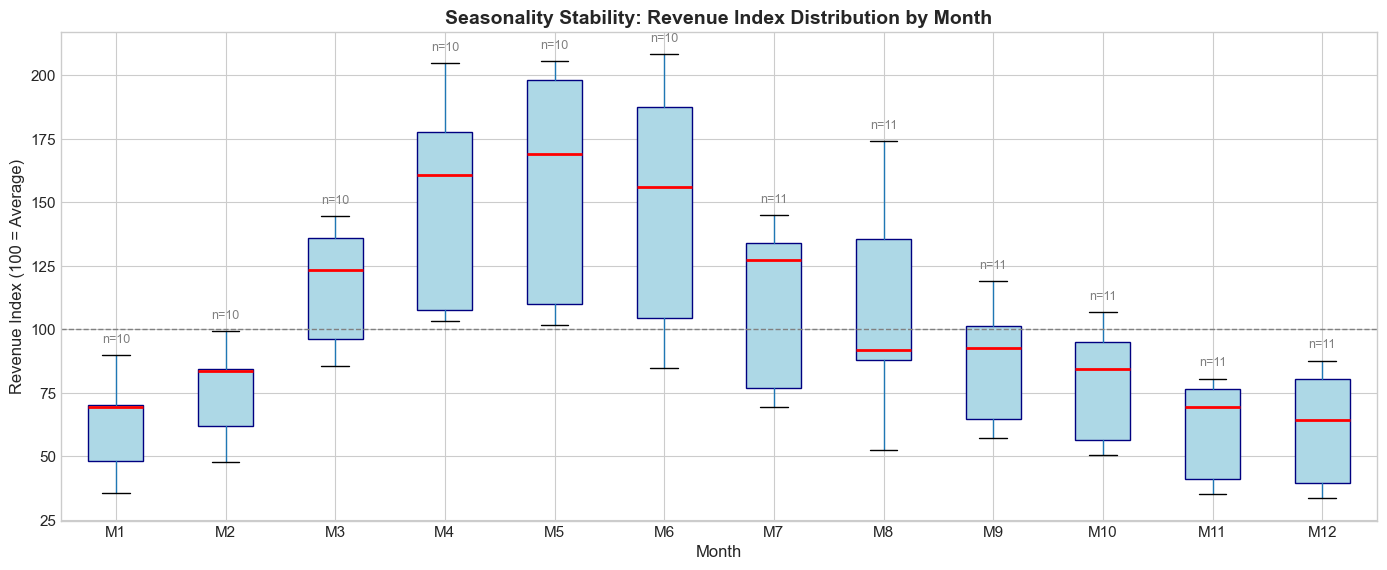


📊 Biểu đồ đã lưu: monthly_seasonality_boxplot.png


In [36]:
# Seasonality Boxplot
fig, ax = plt.subplots(figsize=(14, 6))
monthly.boxplot(column='rev_index', by='month', ax=ax, 
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
ax.axhline(y=100, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Revenue Index (100 = Average)', fontsize=12)
ax.set_title('Seasonality Stability: Revenue Index Distribution by Month', fontweight='bold', fontsize=14)
plt.suptitle('')
ax.set_xticklabels([f'M{i}' for i in range(1, 13)])

# Add count annotations
for i, month in enumerate(range(1, 13), 1):
    count = len(monthly[monthly['month'] == month])
    ax.annotate(f'n={count}', xy=(i, monthly[monthly['month'] == month]['rev_index'].max() + 5),
                ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'monthly_seasonality_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Biểu đồ đã lưu: monthly_seasonality_boxplot.png")

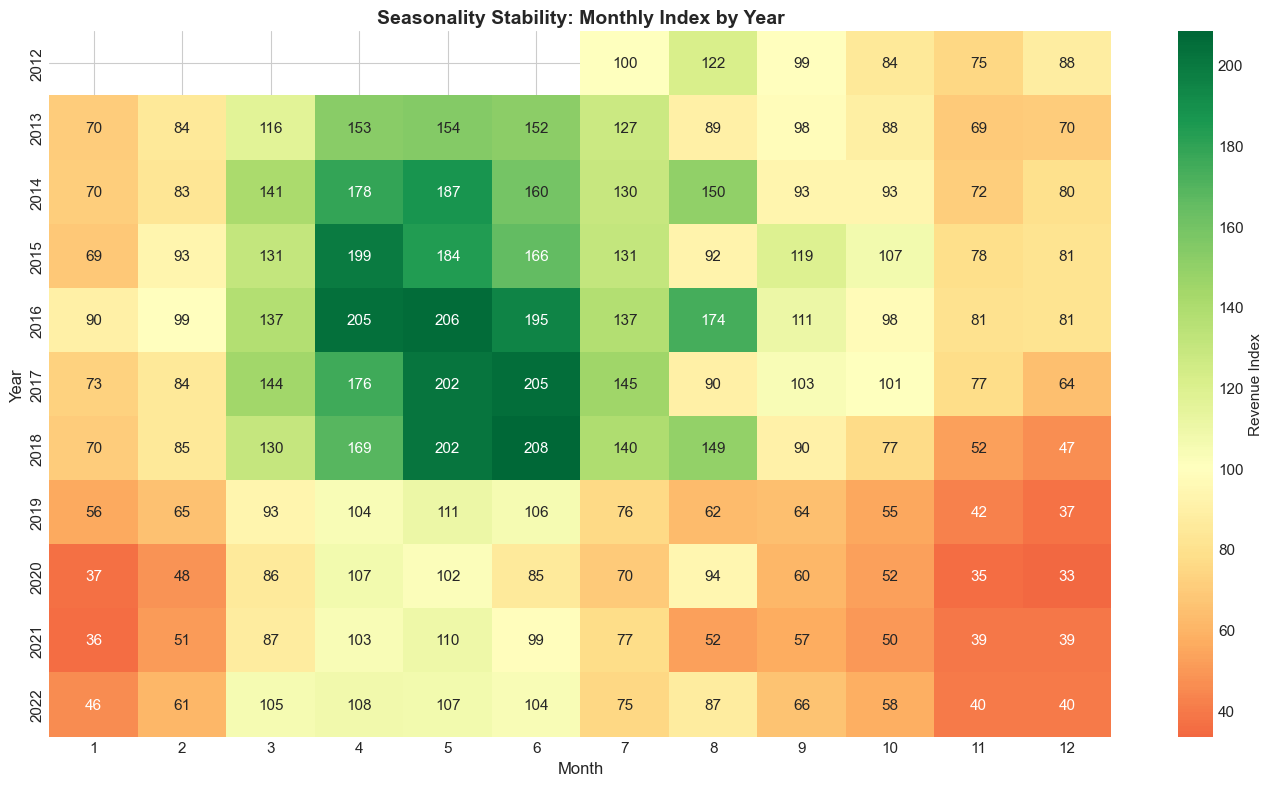


📊 Biểu đồ đã lưu: seasonality_stability_heatmap.png


In [37]:
# Seasonality Stability Heatmap
fig, ax = plt.subplots(figsize=(14, 8))
stability_data = monthly_index_by_year.T
sns.heatmap(stability_data, annot=True, fmt='.0f', cmap='RdYlGn', center=100, ax=ax,
            cbar_kws={'label': 'Revenue Index'})
ax.set_title('Seasonality Stability: Monthly Index by Year', fontweight='bold', fontsize=14)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Year', fontsize=12)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'seasonality_stability_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Biểu đồ đã lưu: seasonality_stability_heatmap.png")

In [38]:
# Traffic-Revenue Lag Analysis
daily_sales = sales.groupby('Date_only')['Revenue'].sum().reset_index()
daily_traffic = web_traffic.groupby('Date_only').agg({
    'sessions': 'sum',
    'unique_visitors': 'sum'
}).reset_index()

daily = daily_sales.merge(daily_traffic, on='Date_only', how='inner')
print(f"\n📊 Merged daily data: {len(daily)} days")

# Calculate correlations at various lags
lags = [0, 1, 3, 7, 14, 30]
lag_correlations = []

for lag in lags:
    if lag == 0:
        corr = daily['sessions'].corr(daily['Revenue'])
    else:
        shifted_traffic = daily['sessions'].shift(lag)
        corr = shifted_traffic.corr(daily['Revenue'])
    lag_correlations.append({'lag': lag, 'correlation': corr})

lag_df = pd.DataFrame(lag_correlations)

print("\n📊 LAG CORRELATION (Traffic vs Revenue):")
print("="*55)
print(f"{'Lag (days)':<12} {'Correlation':>12} {'Interpretation':<20}")
print("-"*55)
for _, row in lag_df.iterrows():
    if abs(row['correlation']) < 0.3:
        interp = 'Yếu'
    elif abs(row['correlation']) < 0.6:
        interp = 'Trung bình'
    else:
        interp = 'Mạnh'
    print(f"{row['lag']:>10}d {row['correlation']:>11.3f} {interp:<20}")

best_lag = lag_df.loc[lag_df['correlation'].abs().idxmax()]
print(f"\n📈 Best lag: {int(best_lag['lag'])} days (r = {best_lag['correlation']:.3f})")
print("\n⚠️ WARNING: Traffic có correlation yếu-trung bình với revenue")
print("   => Chưa nên dùng traffic như tín hiệu dự báo độc lập")


📊 Merged daily data: 3652 days

📊 LAG CORRELATION (Traffic vs Revenue):
Lag (days)    Correlation Interpretation      
-------------------------------------------------------
       0.0d       0.321 Trung bình          
       1.0d       0.322 Trung bình          
       3.0d       0.312 Trung bình          
       7.0d       0.309 Trung bình          
      14.0d       0.288 Yếu                 
      30.0d       0.213 Yếu                 

📈 Best lag: 1 days (r = 0.322)

⚠️ WARNING: Traffic có correlation yếu-trung bình với revenue
   => Chưa nên dùng traffic như tín hiệu dự báo độc lập


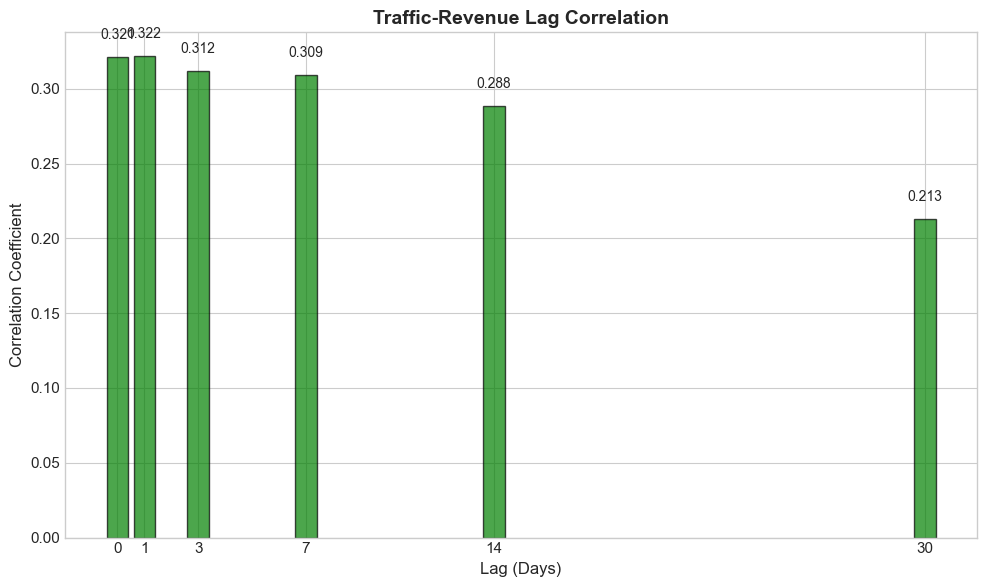


📊 Biểu đồ đã lưu: traffic_revenue_lag_correlation.png


In [39]:
# Traffic-Revenue Lag Correlation Chart
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in lag_df['correlation']]
bars = ax.bar(lag_df['lag'], lag_df['correlation'], color=colors, edgecolor='black', alpha=0.7)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('Lag (Days)', fontsize=12)
ax.set_ylabel('Correlation Coefficient', fontsize=12)
ax.set_title('Traffic-Revenue Lag Correlation', fontweight='bold', fontsize=14)
ax.set_xticks(lags)

# Add value labels
for bar, corr in zip(bars, lag_df['correlation']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{corr:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'traffic_revenue_lag_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Biểu đồ đã lưu: traffic_revenue_lag_correlation.png")

---

## 5 — Cấp độ 4: PRESCRIPTIVE — Đề xuất

**Câu hỏi**: Cần làm gì để cải thiện doanh thu?

In [40]:
# Evidence-Based Recommendations
print("\n📋 EVIDENCE-BASED RECOMMENDATIONS")
print("="*80)

recommendations = [
    {
        'id': 1,
        'category': 'Q2 Planning',
        'rec': 'Chuẩn bị inventory/capacity cho Q2',
        'evidence': 'Q2 consistently cao, sessions +111% so với Q4',
        'confidence': 'Cao',
        'risk': 'Trung bình - Peaks gần đây có xu hướng thấp hơn',
        'action': 'Build stock 1-2 tháng trước Q2',
        'owner': 'Ops + Merchandising'
    },
    {
        'id': 2,
        'category': 'Q2 Planning',
        'rec': 'Không over-scale theo peak cũ',
        'evidence': 'Peak months gần đây chỉ đạt 100-110%, không phải 200%+',
        'confidence': 'Trung bình',
        'risk': 'Over-investment nếu peak không đạt kỳ vọng',
        'action': 'Plan với conservative estimate (e.g., 120-130% thay vì 200%)',
        'owner': 'Ops + Finance'
    },
    {
        'id': 3,
        'category': 'Q4 Investigation',
        'rec': 'Điều tra traffic drop trước khi hành động lớn',
        'evidence': 'Q4 sessions -47%, nhưng conversion +8% so với Q2. Conversion cao hơn gợi ý intent có sẵn.',
        'confidence': 'Cao cho problem, Thấp cho cause',
        'risk': 'Action sai có thể lãng phí budget',
        'action': 'Survey/exit interviews Q4 visitors; Phân tích competitor activity Q4',
        'owner': 'Analytics + Marketing'
    },
    {
        'id': 4,
        'category': 'Tet Period',
        'rec': 'Kiểm tra fulfillment capacity trước khi tăng marketing',
        'evidence': 'T1-T2 consistently thấp (61-75%)',
        'confidence': 'Cao',
        'risk': 'Logistics bottleneck có thể tệ hơn với nhiều orders hơn',
        'action': 'Phân tích order completion rate by date; So sánh fulfillment time T1-T2 vs other months',
        'owner': 'Ops + Analytics'
    },
    {
        'id': 5,
        'category': 'Traffic Monitoring',
        'rec': 'Dùng traffic như monitoring signal cùng Orders, Conversion, AOV',
        'evidence': 'r = 0.32 (yếu-trung bình)',
        'confidence': 'Thấp',
        'risk': 'Có thể cho tín hiệu sai',
        'action': 'Monitor hàng ngày, không phản ứng với single-day drops',
        'owner': 'Analytics'
    }
]

for rec in recommendations:
    print(f"\n{rec['id']}. [{rec['category']}] {rec['rec']}")
    print(f"   Evidence: {rec['evidence']}")
    print(f"   Confidence: {rec['confidence']}")
    print(f"   Risk: {rec['risk']}")
    print(f"   Action: {rec['action']}")
    print(f"   Owner: {rec['owner']}")


📋 EVIDENCE-BASED RECOMMENDATIONS

1. [Q2 Planning] Chuẩn bị inventory/capacity cho Q2
   Evidence: Q2 consistently cao, sessions +111% so với Q4
   Confidence: Cao
   Risk: Trung bình - Peaks gần đây có xu hướng thấp hơn
   Action: Build stock 1-2 tháng trước Q2
   Owner: Ops + Merchandising

2. [Q2 Planning] Không over-scale theo peak cũ
   Evidence: Peak months gần đây chỉ đạt 100-110%, không phải 200%+
   Confidence: Trung bình
   Risk: Over-investment nếu peak không đạt kỳ vọng
   Action: Plan với conservative estimate (e.g., 120-130% thay vì 200%)
   Owner: Ops + Finance

3. [Q4 Investigation] Điều tra traffic drop trước khi hành động lớn
   Evidence: Q4 sessions -47%, nhưng conversion +8% so với Q2. Conversion cao hơn gợi ý intent có sẵn.
   Confidence: Cao cho problem, Thấp cho cause
   Risk: Action sai có thể lãng phí budget
   Action: Survey/exit interviews Q4 visitors; Phân tích competitor activity Q4
   Owner: Analytics + Marketing

4. [Tet Period] Kiểm tra fulfillment capa

In [41]:
# Các kết luận/hành động cần tránh
print("\n⚠️ CÁC KẾT LUẬN/HÀNH ĐỘNG CẦN TRÁNH")
print("="*80)

avoid_list = [
    ("Q4 thấp vì khách hàng chi tiêu cho Tết", "Chưa đủ bằng chứng - Không có data"),
    ("Tăng marketing 50% cho Q2", "Chưa đủ bằng chứng - Không có ROI data"),
    ("Traffic dự báo revenue", "Overclaimed - r = 0.32 chỉ là yếu-trung bình"),
    ("Q2 chắc chắn peak ở 200%", "Chưa đủ bằng chứng - Peak đang giảm"),
    ("Marketing Tet sẽ boost sales", "Rủi ro - Có thể làm nặng fulfillment hơn"),
    ("Supply is not the bottleneck", "Chưa đủ bằng chứng - Thiếu stockout/fulfillment data")
]

for avoid, reason in avoid_list:
    print(f"\n❌ Tránh: \"{avoid}\"")
    print(f"   Lý do: {reason}")


⚠️ CÁC KẾT LUẬN/HÀNH ĐỘNG CẦN TRÁNH

❌ Tránh: "Q4 thấp vì khách hàng chi tiêu cho Tết"
   Lý do: Chưa đủ bằng chứng - Không có data

❌ Tránh: "Tăng marketing 50% cho Q2"
   Lý do: Chưa đủ bằng chứng - Không có ROI data

❌ Tránh: "Traffic dự báo revenue"
   Lý do: Overclaimed - r = 0.32 chỉ là yếu-trung bình

❌ Tránh: "Q2 chắc chắn peak ở 200%"
   Lý do: Chưa đủ bằng chứng - Peak đang giảm

❌ Tránh: "Marketing Tet sẽ boost sales"
   Lý do: Rủi ro - Có thể làm nặng fulfillment hơn

❌ Tránh: "Supply is not the bottleneck"
   Lý do: Chưa đủ bằng chứng - Thiếu stockout/fulfillment data


---

## 6 — Tổng kết & Khuyến nghị

In [42]:
# Key Takeaways
print("\n📌 KEY TAKEAWAYS")
print("="*80)
print("""
1. Q2 > Q4 là pattern đáng tin theo DIRECTION
   - Q2 thường cao hơn Q4 qua tất cả các năm
   - Tuy nhiên, MAGNITUDE không ổn định và đang giảm

2. Magnitude của seasonality không ổn định
   - CV = 25-35% cho hầu hết tháng
   - Peak months có thể dao động từ 85% đến 206%

3. Traffic/sessions là driver quan sát được quan trọng nhất
   - Q2 mạnh chủ yếu do traffic cao hơn
   - Q4 thấp chủ yếu do traffic thấp hơn

4. Q4 thấp KHÔNG PHẢI do conversion thấp
   - Conversion Q4 (0.78%) CAO HƠN Q2 (0.72%)
   - Gợi ý intent có sẵn, nhưng ít người đến

5. Không nên overclaim causality
   - Correlation ≠ Causation
   - Chưa đủ data để kết luận root cause
""")


📌 KEY TAKEAWAYS

1. Q2 > Q4 là pattern đáng tin theo DIRECTION
   - Q2 thường cao hơn Q4 qua tất cả các năm
   - Tuy nhiên, MAGNITUDE không ổn định và đang giảm

2. Magnitude của seasonality không ổn định
   - CV = 25-35% cho hầu hết tháng
   - Peak months có thể dao động từ 85% đến 206%

3. Traffic/sessions là driver quan sát được quan trọng nhất
   - Q2 mạnh chủ yếu do traffic cao hơn
   - Q4 thấp chủ yếu do traffic thấp hơn

4. Q4 thấp KHÔNG PHẢI do conversion thấp
   - Conversion Q4 (0.78%) CAO HƠN Q2 (0.72%)
   - Gợi ý intent có sẵn, nhưng ít người đến

5. Không nên overclaim causality
   - Correlation ≠ Causation
   - Chưa đủ data để kết luận root cause



In [43]:
# Limitations
print("\n⚠️ LIMITATIONS")
print("="*80)
print("""
1. Traffic có thể phản ánh marketing activity, không phải pure demand
2. Conversion rate = orders/sessions chỉ là proxy, không phải true funnel
3. Correlation/lag không chứng minh causality
4. Không có marketing spend data - Không đánh giá được marketing ROI
5. Revenue mismatch 4.6% - Data quality issue
6. Không có stockout/fulfillment data - Chưa loại trừ supply constraint
7. Magnitude seasonality đang giảm - Tương lai có thể ít seasonal hơn
""")


⚠️ LIMITATIONS

1. Traffic có thể phản ánh marketing activity, không phải pure demand
2. Conversion rate = orders/sessions chỉ là proxy, không phải true funnel
3. Correlation/lag không chứng minh causality
4. Không có marketing spend data - Không đánh giá được marketing ROI
5. Revenue mismatch 4.6% - Data quality issue
6. Không có stockout/fulfillment data - Chưa loại trừ supply constraint
7. Magnitude seasonality đang giảm - Tương lai có thể ít seasonal hơn



In [44]:
# Next Steps
print("\n📋 NEXT STEPS")
print("="*80)
print("""
| Priority | Action | Owner |
|----------|--------|-------|
| Cao | Chuẩn bị inventory Q2 (conservative) | Ops |
| Cao | Điều tra Q4 traffic drop | Analytics + Marketing |
| Cao | Kiểm tra Tet fulfillment | Ops + Analytics |
| Trung bình | Survey Q4 visitors | Marketing |
| Trung bình | Test Q4 marketing | Marketing |
| Thấp | Weekend optimization | Marketing |
""")

print("\n✅ ANALYSIS COMPLETE - V3.1")
print("="*80)


📋 NEXT STEPS

| Priority | Action | Owner |
|----------|--------|-------|
| Cao | Chuẩn bị inventory Q2 (conservative) | Ops |
| Cao | Điều tra Q4 traffic drop | Analytics + Marketing |
| Cao | Kiểm tra Tet fulfillment | Ops + Analytics |
| Trung bình | Survey Q4 visitors | Marketing |
| Trung bình | Test Q4 marketing | Marketing |
| Thấp | Weekend optimization | Marketing |


✅ ANALYSIS COMPLETE - V3.1
